# LC updated cal/val runs August 2026


In [68]:
# Install required packages
import pandas as pd
from pathlib import Path
import os                      
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [71]:
# Load observation discharge data into a dataframe
obs = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/Results/Results1/daily_discharge_0531.txt", sep="\\t")

obs["Time"] = pd.to_datetime(obs["Time"])
obs = obs.set_index("Time")
print(obs.head())

            Shiplaw_Burn  Middle_Burn  Middle_Longcote  Kidston_Mill
Time                                                                
2011-03-22         0.016        0.012            0.025         0.942
2011-03-23         0.014        0.011            0.023         0.841
2011-03-24         0.012        0.010            0.022         0.760
2011-03-25         0.006        0.010            0.020         0.709
2011-03-26         0.004        0.009            0.020         0.667


/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_48200/3963265554.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  obs = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/Results/Results1/daily_discharge_0531.txt", sep="\\t")


In [72]:
# Load modelled discharge data

full = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/NewResults/LC_outputs/Eddleston_LC_scen1newMDetailedTS_M11.txt", sep="\\t")
full["Time"] = pd.to_datetime(full["Time"])
full = full.set_index("Time")

/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_48200/452385429.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  full = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/NewResults/LC_outputs/Eddleston_LC_scen1newMDetailedTS_M11.txt", sep="\\t")


In [73]:
print(full)

                     Shiplaw_Burn  Middle_Burn  Middle_Longcote  Kidston_Mill
Time                                                                         
2011-03-22 00:00:50      0.000000     0.000000         0.000000      0.000000
2011-03-23 00:00:50      0.017421     0.009732         0.063824      0.237469
2011-03-24 00:00:50      0.014834     0.011756         0.067051      0.282687
2011-03-25 00:00:50      0.013796     0.009765         0.059611      0.233796
2011-03-26 00:00:50      0.013334     0.008159         0.054311      0.204925
...                           ...          ...              ...           ...
2020-03-01 00:03:20      0.554566     0.332147         0.244241      8.705860
2020-03-02 00:03:20      0.185327     0.149189         0.266299      4.085090
2020-03-03 00:03:20      0.066223     0.057753         0.230004      1.506050
2020-03-04 00:03:20      0.047694     0.047984         0.191012      1.188900
2020-03-04 23:26:40      0.042544     0.038518         0.163776 

In [74]:
# Split the full time series into calibration and validation periods

if 'full' in globals():
    ts = full.copy()
else:
    ts = obs.copy()

if not isinstance(ts.index, pd.DatetimeIndex):
    ts.index = pd.to_datetime(ts.index)

ts = ts.sort_index()

cal_start = pd.Timestamp('2011-03-23')
cal_end = pd.Timestamp('2016-03-22')
val_start = pd.Timestamp('2016-03-22')
val_end = pd.Timestamp('2020-03-05')

calibration = ts.loc[cal_start:cal_end].copy()
validation = ts.loc[val_start:val_end].copy()

# Exclude the split date from calibration to keep the periods non-overlapping
calibration = calibration.loc[calibration.index < val_start]

print(f'Calibration rows: {len(calibration)}')
print(f'Validation rows: {len(validation)}')
print('\nCalibration period head:')
print(calibration.head())
print('\nValidation period head:')
print(validation.head())

Calibration rows: 1826
Validation rows: 1445

Calibration period head:
                     Shiplaw_Burn  Middle_Burn  Middle_Longcote  Kidston_Mill
Time                                                                         
2011-03-23 00:00:50      0.017421     0.009732         0.063824      0.237469
2011-03-24 00:00:50      0.014834     0.011756         0.067051      0.282687
2011-03-25 00:00:50      0.013796     0.009765         0.059611      0.233796
2011-03-26 00:00:50      0.013334     0.008159         0.054311      0.204925
2011-03-27 00:00:50      0.012893     0.008720         0.048589      0.194198

Validation period head:
                     Shiplaw_Burn  Middle_Burn  Middle_Longcote  Kidston_Mill
Time                                                                         
2016-03-22 00:03:20      0.015592     0.009385         0.036970      0.194439
2016-03-23 00:03:20      0.015326     0.008425         0.034833      0.185294
2016-03-24 00:03:20      0.015489     0.008988

In [75]:
# Normalise first
for df in [obs, full]:
    df.index = pd.to_datetime(df.index).normalize()

ts = full.copy().sort_index()

calibration = ts.loc["2011-03-23":"2016-03-22"].copy()
validation = ts.loc["2016-03-22":"2020-03-05"].copy()

calibration = calibration.loc[calibration.index < pd.Timestamp("2016-03-22")]
validation = validation.loc[validation.index >= pd.Timestamp("2016-03-22")]

obs_cal = obs.loc["2011-03-23":"2016-03-22"]
obs_val = obs.loc["2016-03-23":"2020-03-05"]


# Merge data
merged_cal = pd.merge(
    obs_cal, calibration,
    left_index=True, right_index=True,
    how="inner", suffixes=("_obs", "_cal")
)

merged_val = pd.merge(
    obs_val, validation,
    left_index=True, right_index=True,
    how="inner", suffixes=("_obs", "_val")
)

In [76]:
# Calibration stats

gauges = ["Shiplaw_Burn", "Middle_Burn", "Middle_Longcote", "Kidston_Mill"]
scenarios = ["cal"]

r_table = {}

for g in gauges:
    r_table[g] = {}
    for s in scenarios:
        mod_col = f"{g}_{s}"
        obs_col = f"{g}_obs"
        r_table[g][s] = merged_cal[mod_col].corr(merged_cal[obs_col])

# Convert to DataFrame
r_df = pd.DataFrame(r_table).T
r_df


,cal
Shiplaw_Burn,0.820696
Middle_Burn,0.788697
Middle_Longcote,0.851546
Kidston_Mill,0.888928


In [77]:
# NSE stats 

def nse(sim, obs):
    sim = np.array(sim)
    obs = np.array(obs)
    return 1 - np.sum((sim - obs)**2) / np.sum((obs - obs.mean())**2)

nse_table = {}

for g in gauges:
    nse_table[g] = {}
    for s in scenarios:
        mod_col = f"{g}_{s}"
        obs_col = f"{g}_obs"
        nse_table[g][s] = nse(merged_cal[mod_col], merged_cal[obs_col])

nse_df = pd.DataFrame(nse_table).T
nse_df

,cal
Shiplaw_Burn,0.648568
Middle_Burn,0.507286
Middle_Longcote,0.709477
Kidston_Mill,0.698016


In [54]:
# Validation stats
gauges = ["Shiplaw_Burn", "Middle_Burn", "Middle_Longcote", "Kidston_Mill"]
scenarios = ["val"]

r_tableval = {}

for g in gauges:
    r_tableval[g] = {}
    for s in scenarios:
        mod_col = f"{g}_{s}"
        obs_col = f"{g}_obs"
        r_tableval[g][s] = merged_val[mod_col].corr(merged_val[obs_col])

# Convert to DataFrame
r_dfval = pd.DataFrame(r_tableval).T
print(r_dfval)

                      val
Shiplaw_Burn     0.724139
Middle_Burn      0.648997
Middle_Longcote  0.726505
Kidston_Mill     0.823118


In [55]:
# NSE stats for validation run

def nse(sim, obs):
    sim = np.array(sim)
    obs = np.array(obs)
    return 1 - np.sum((sim - obs)**2) / np.sum((obs - obs.mean())**2)

nse_tableval = {}

for g in gauges:
    nse_tableval[g] = {}
    for s in scenarios:
        mod_col = f"{g}_{s}"
        obs_col = f"{g}_obs"
        nse_tableval[g][s] = nse(merged_val[mod_col], merged_val[obs_col])

nse_dfval = pd.DataFrame(nse_tableval).T
nse_dfval

,val
Shiplaw_Burn,0.490014
Middle_Burn,0.272592
Middle_Longcote,0.516980
Kidston_Mill,0.557133


In [56]:
# PBIAS stats

def pbias(sim, obs):
    sim = np.array(sim)
    obs = np.array(obs)
    # PBIAS = 100 * sum(sim - obs) / sum(obs)
    return 100.0 * np.sum(sim - obs) / np.sum(obs)

# Calibration PBIAS
pbias_tablecal = {}
for g in gauges:
    pbias_tablecal[g] = {}
    mod_col = f"{g}_cal"
    obs_col = f"{g}_obs"
    pbias_tablecal[g]["cal"] = pbias(merged_cal[mod_col], merged_cal[obs_col])

pbias_df = pd.DataFrame(pbias_tablecal).T

# Validation PBIAS
pbias_tableval = {}
for g in gauges:
    pbias_tableval[g] = {}
    mod_col = f"{g}_val"
    obs_col = f"{g}_obs"
    pbias_tableval[g]["val"] = pbias(merged_val[mod_col], merged_val[obs_col])

pbias_dfval = pd.DataFrame(pbias_tableval).T

print('Calibration PBIAS (percent):')
print(pbias_df)
print('\nValidation PBIAS (percent):')
print(pbias_dfval)


Calibration PBIAS (percent):
                       cal
Shiplaw_Burn      1.059510
Middle_Burn     -36.031539
Middle_Longcote  -8.577153
Kidston_Mill    -35.912368

Validation PBIAS (percent):
                       val
Shiplaw_Burn    -19.190717
Middle_Burn     -53.580763
Middle_Longcote  11.245247
Kidston_Mill    -43.883768


In [78]:
# Combined stats for calibration and validation

# Rename single-scenario columns to descriptive metric names
r_df_ren = r_df.rename(columns={col: 'r' for col in r_df.columns})
nse_df_ren = nse_df.rename(columns={col: 'NSE' for col in nse_df.columns})
pbias_df_ren = pbias_df.rename(columns={col: 'PBIAS' for col in pbias_df.columns})

metrics_df = pd.concat([r_df_ren, nse_df_ren, pbias_df_ren], axis=1)
metrics_df

# Validation combined metrics
r_dfval_ren = r_dfval.rename(columns={col: 'r' for col in r_dfval.columns})
nse_dfval_ren = nse_dfval.rename(columns={col: 'NSE' for col in nse_dfval.columns})
pbias_dfval_ren = pbias_dfval.rename(columns={col: 'PBIAS' for col in pbias_dfval.columns})

metrics_df_val = pd.concat([r_dfval_ren, nse_dfval_ren, pbias_dfval_ren], axis=1)
metrics_df_val


,r,NSE,PBIAS
Shiplaw_Burn,0.724139,0.490014,-19.190717
Middle_Burn,0.648997,0.272592,-53.580763
Middle_Longcote,0.726505,0.516980,11.245247
Kidston_Mill,0.823118,0.557133,-43.883768


# Panel figures

## Monthly regimes

In [79]:
# Computing monthly regimes

obs_regime = obs.groupby(obs.index.month).mean()

full_regime = full.groupby(full.index.month).mean()

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

obs_regime.index = month_names
full_regime.index = month_names

In [84]:
def create_regime(df_name):
    return pd.DataFrame({
        "Modelled": full.groupby(full.index.month)[df_name].mean(),
        "Observed": obs.groupby(obs.index.month)[df_name].mean()
    })

In [85]:
regimes_SB = create_regime("Shiplaw_Burn")
regimes_MB = create_regime("Middle_Burn")
regimes_ML = create_regime("Middle_Longcote")
regimes_KM = create_regime("Kidston_Mill")

for df in [regimes_SB, regimes_MB, regimes_ML, regimes_KM]:
    df.index = month_names

In [86]:
# print monthly means
print(regimes_SB)

     Modelled  Observed
Jan  0.097532  0.080903
Feb  0.082664  0.070184
Mar  0.045591  0.043194
Apr  0.025800  0.023481
May  0.014041  0.013075
Jun  0.017718  0.025715
Jul  0.018038  0.034118
Aug  0.013643  0.033029
Sep  0.020151  0.031341
Oct  0.033031  0.040341
Nov  0.048052  0.063567
Dec  0.110125  0.101746


In [87]:
color_dict = {
    "Observed": "grey",
    "Modelled": "royalblue"
}

In [88]:
print(regimes_SB)

     Modelled  Observed
Jan  0.097532  0.080903
Feb  0.082664  0.070184
Mar  0.045591  0.043194
Apr  0.025800  0.023481
May  0.014041  0.013075
Jun  0.017718  0.025715
Jul  0.018038  0.034118
Aug  0.013643  0.033029
Sep  0.020151  0.031341
Oct  0.033031  0.040341
Nov  0.048052  0.063567
Dec  0.110125  0.101746


## Merge cal and val to plot full time-series

In [94]:
# Same but for mean monthly discharge 

# Convert daily to monthly mean
observations_monthly = obs.resample("ME").mean()
calandval_monthly = full.resample("ME").mean()

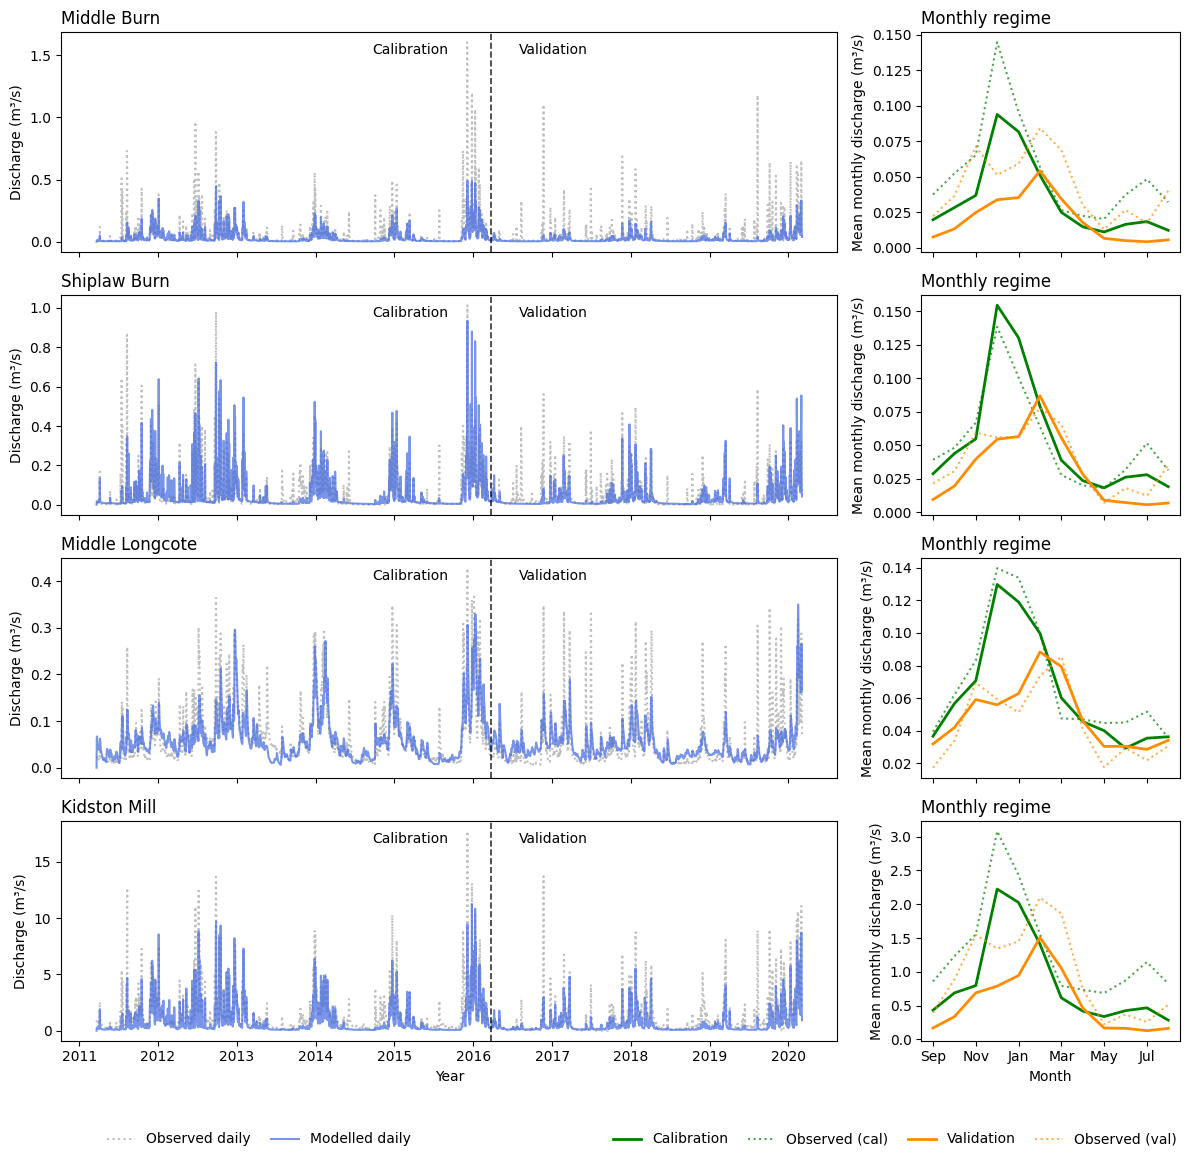

In [93]:
# Merge panels for cal and val timeseries and regimes

fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 12),
    gridspec_kw={"width_ratios": [3, 1]},
    sharex='col'
)

axes = axes.reshape(4, 2)

gauges = ["Middle_Burn", "Shiplaw_Burn", "Middle_Longcote", "Kidston_Mill"]
month_names = ["Sep","Oct","Nov","Dec","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug"]
month_order = [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]  # September to August

regimes = []
for gauge in gauges:
    regime_df = pd.DataFrame({
        "Observed (cal)": obs_cal.groupby(obs_cal.index.month)[gauge].mean(),
        "Observed (val)": obs_val.groupby(obs_val.index.month)[gauge].mean(),
        "Model (cal)": calibration.groupby(calibration.index.month)[gauge].mean(),
        "Model (val)": validation.groupby(validation.index.month)[gauge].mean(),
    })
    regime_df = regime_df.reindex(month_order)
    regime_df.index = month_names
    regimes.append(regime_df)

split_date = pd.to_datetime("2016-03-22")

# Plotting loop
for i, gauge in enumerate(gauges):

    # Left: timeseries
    ax_ts = axes[i, 0]
    ax_ts.plot(obs.index, obs[gauge], label="Observed daily", linestyle="dotted", color="grey", alpha=0.5)
    ax_ts.plot(full.index, full[gauge], alpha=0.7, label="Modelled daily", color="royalblue")
    ax_ts.axvline(split_date, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    ax_ts.text(
        0.4,
        0.95,
        "Calibration",
        transform=ax_ts.transAxes,
        fontsize=10,
        ha="left",
        va="top",
        color="black"
    )
    ax_ts.text(
        0.59,
        0.95,
        "Validation",
        transform=ax_ts.transAxes,
        fontsize=10,
        ha="left",
        va="top",
        color="black"
    )
    ax_ts.set_title(gauge.replace("_", " "), loc="left")
    ax_ts.set_ylabel("Discharge (m³/s)")

    # Right: regime
    ax_reg = axes[i, 1]

    # Plot calibration and validation regimes with distinct styling
    ax_reg.plot(
        regimes[i].index,
        regimes[i]["Model (cal)"],
        color="green",
        linewidth=2,
        label="Calibration"
    )
    ax_reg.plot(
        regimes[i].index,
        regimes[i]["Observed (cal)"],
        color="green",
        alpha=0.7,
        linestyle="dotted",
        linewidth=1.5,
        label="Observed (cal)"
    )
    ax_reg.plot(
        regimes[i].index,
        regimes[i]["Model (val)"],
        color="darkorange",
        linewidth=2,
        label="Validation"
    )
    ax_reg.plot(
        regimes[i].index,
        regimes[i]["Observed (val)"],
        color="darkorange",
        alpha=0.7,
        linestyle="dotted",
        linewidth=1.5,
        label="Observed (val)"
    )

    ax_reg.set_title("Monthly regime", loc="left")
    ax_reg.set_ylabel("Mean monthly discharge (m³/s)")
    ax_reg.grid(False)


# Yearly ticks on the left column
for i in range(4):
    ax = axes[i, 0]
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(ticker.NullLocator())

# Monthly ticks on the right column
tick_labels = ["Sep", "Nov", "Jan", "Mar", "May", "Jul"]

for i in range(4):
    ax = axes[i, 1]
    ax.set_xticks([0, 2, 4, 6, 8, 10])
    ax.set_xticklabels(tick_labels)
    ax.xaxis.set_minor_locator(ticker.NullLocator())


# Bottom x-labels
axes[3, 0].set_xlabel("Year")
axes[3, 1].set_xlabel("Month")

# Remove legends from individual subplots
for row in axes:
    for ax in row:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

# Time-series legend underneath the left column
left_handles, left_labels = [], []
for ax in [axes[0, 0]]:
    handles, labels = ax.get_legend_handles_labels()
    left_handles.extend(handles)
    left_labels.extend(labels)

fig.legend(
    left_handles,
    left_labels,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.22, 0.03),
    frameon=False,
    columnspacing=1.5,
    handlelength=2.0,
)

# Regime legend underneath the right column
right_handles, right_labels = [], []
for ax in [axes[0, 1]]:
    handles, labels = ax.get_legend_handles_labels()
    right_handles.extend(handles)
    right_labels.extend(labels)

fig.legend(
    right_handles,
    right_labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.75, 0.03),
    frameon=False,
    columnspacing=1.4,
    handlelength=2.0,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig("Figure31.png", dpi=400, bbox_inches='tight')

plt.show()


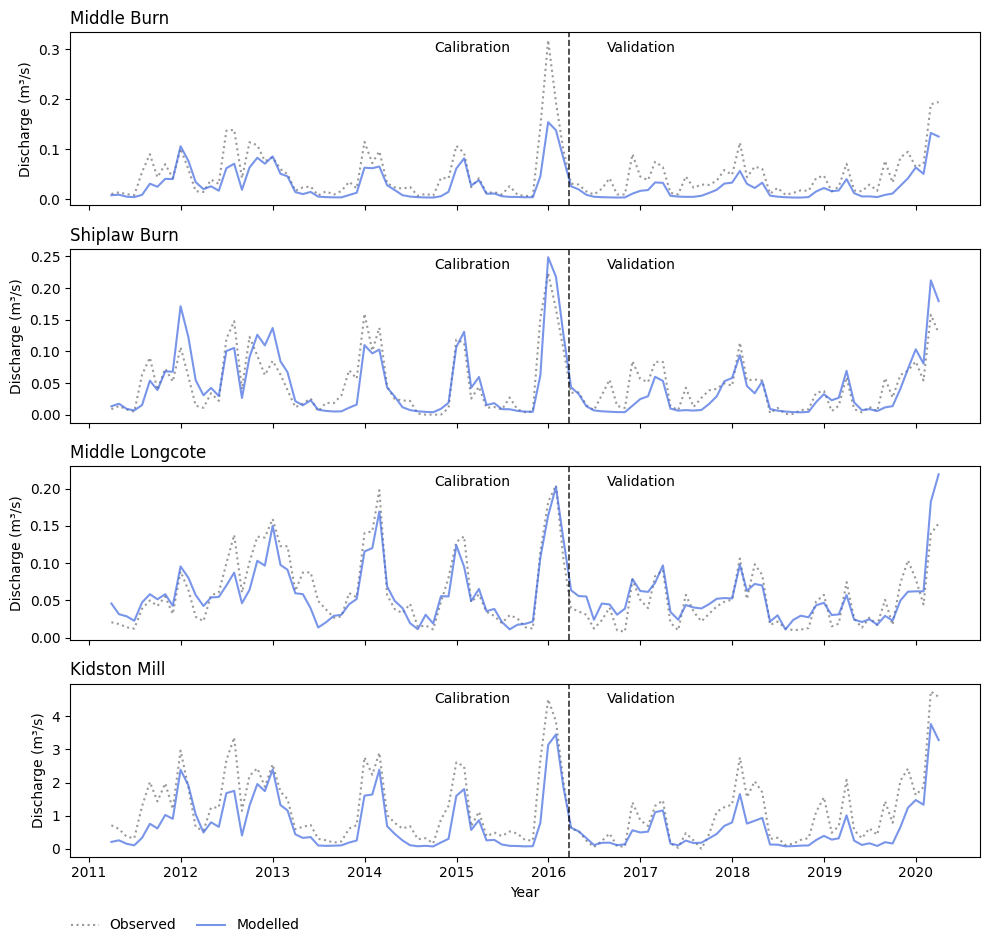

In [95]:
# Now for monthly discharge

fig, axes = plt.subplots(
    4, 1,
    figsize=(10, 10),
    sharex=True
)

gauges = ["Middle_Burn", "Shiplaw_Burn", "Middle_Longcote", "Kidston_Mill"]
split_date = pd.to_datetime("2016-03-22")

for i, gauge in enumerate(gauges):
    ax = axes[i]

    ax.plot(
        observations_monthly.index,
        observations_monthly[gauge],
        label="Observed",
        linestyle="dotted",
        color="grey",
        alpha=0.8
    )
    ax.plot(
        calandval_monthly.index,
        calandval_monthly[gauge],
        alpha=0.7,
        label="Modelled",
        color="royalblue"
    )
    ax.axvline(split_date, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.text(
        0.4,
        0.95,
        "Calibration",
        transform=ax.transAxes,
        fontsize=10,
        ha="left",
        va="top",
        color="black"
    )
    ax.text(
        0.59,
        0.95,
        "Validation",
        transform=ax.transAxes,
        fontsize=10,
        ha="left",
        va="top",
        color="black"
    )
    ax.set_title(gauge.replace("_", " "), loc="left")
    ax.set_ylabel("Discharge (m³/s)")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(ticker.NullLocator())

axes[-1].set_xlabel("Year")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.19, 0.05),
    frameon=False,
    columnspacing=1.5,
    handlelength=2.0,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("Figure32.png", dpi=400, bbox_inches='tight')

plt.show()
